In [1]:
!pip install open_clip_torch faiss-cpu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 60.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn.functional as F
from PIL import Image
from open_clip import create_model_from_pretrained, get_tokenizer
import faiss
import numpy as np
import json
import h5py
from tqdm import tqdm
import requests

In [3]:
model, preprocess = create_model_from_pretrained('hf-hub:apple/DFN5B-CLIP-ViT-H-14')
tokenizer = get_tokenizer('ViT-H-14')
model.cuda()
print()

open_clip_pytorch_model.bin:   0%|          | 0.00/3.94G [00:00<?, ?B/s]

open_clip_config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

In [4]:
data = {}
with h5py.File("/kaggle/input/msvd-dataset/msrvtt_frames.hdf5", "r") as fs:
    for key in tqdm(fs.keys()):
        frames = (fs[key][()] * 255).clip(0, 255).astype(np.uint8)
        data[key] = Image.fromarray(frames)    

100%|██████████| 10000/10000 [01:28<00:00, 113.58it/s]


In [5]:
entities = set()
with open("/kaggle/input/msvd-dataset/msrvtt_entity_total.txt", 'r') as f:
    for line in f:
        parts = line.strip().split('&')
        if len(parts) == 3:
            head, tail, _ = parts
            entities.add(head.strip())
            entities.add(tail.strip())
entities = list(entities)
len(entities)

2724

In [6]:
tokens = tokenizer(entities, context_length=model.context_length)
tokens.shape

torch.Size([2724, 77])

In [7]:
embeddings = []
batch_size = 32
for i in tqdm(range(0, len(tokens), batch_size)):
    if (i + batch_size) % batch_size != 0:
        batch = tokens[i:]
    else:
        batch = tokens[i:i + batch_size] 
    with torch.no_grad():
        text_features = model.encode_text(batch.cuda())
        text_features /= text_features.norm(dim=-1, keepdim=True)
    embeddings.append(text_features.cpu().numpy())
    
text_embeddings = np.vstack(embeddings).astype("float32")
index = faiss.IndexFlatIP(text_embeddings.shape[1])
index.add(text_embeddings)

100%|██████████| 86/86 [00:21<00:00,  3.99it/s]


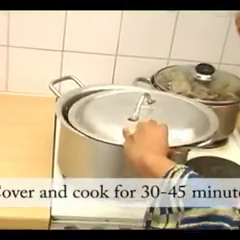

In [11]:
video_id = 'video1'
# video_id = 'vid1125'
data[video_id]

In [12]:
query_image = preprocess(data[video_id]).unsqueeze(0)
with torch.no_grad():
    image_features = model.encode_image(query_image.cuda())
    image_features /= image_features.norm(dim=-1, keepdim=True)

query_embedding = image_features.cpu().numpy().astype("float32")

D, I = index.search(query_embedding, k=6)
for i in I[0]:
    print(entities[i], end=", ")

cooking, boiling, cooker, saucepan, pan, recipe, 

In [14]:
infos = {}
for video_id in tqdm(data.keys()):
    query_image = preprocess(data[video_id]).unsqueeze(0)
    with torch.no_grad():
        image_features = model.encode_image(query_image.cuda())
        image_features /= image_features.norm(dim=-1, keepdim=True)
    
    query_embedding = image_features.cpu().numpy().astype("float32")
    D, I = index.search(query_embedding, k=6)
    
    infos[video_id] = {}
    infos[video_id]['score'] = D[0].tolist()
    infos[video_id]['class'] = []
    for i in I[0]:
        infos[video_id]['class'].append(entities[i])

100%|██████████| 10000/10000 [13:17<00:00, 12.54it/s]


In [15]:
import json
with open("MSRVTT_annotations.json", "w", encoding="utf-8") as f:
    json.dump(infos, f, indent=4)